In [1]:
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run
from copy import copy

from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

In [2]:
api = wandb.Api()

In [3]:
runs_entropy = api.runs(
    "graphcore/llama-mobile", filters={"config.name": "sweep-formats-v1"}
)
runs_vqa = api.runs(
    "graphcore/llama-mobile", filters={"config.name": "sweep-formats-vqa-test"}
)

In [4]:
def cleanup_run_old(run: Run) -> dict[str, any]:
    fmt = run.config["quantisation_formats"][1][1]

    d = {}
    # NOTE: format is None if not-quantised
    d["format"] = None
    d["scaling"] = None
    if fmt["_type"] == "linear":
        el_format = fmt["element_format"]
        type = el_format["_type"]
        if type == "fp":
            d["format"] = f"E{el_format['exponent_bits']}M{el_format['mantissa_bits']}"
        elif type == "int":
            d["format"] = f"INT{el_format['bits_']}"
        else:
            raise ValueError("Unexpected element format _type")
        row, col = fmt["group_shapes"][0]
        if row is None and col is None:
            d["scaling"] = "Tensor"
        elif row == 1 and col is None:
            d["scaling"] = "channel-in"
        elif row is None and col == 1:
            d["scaling"] = "clannel-out"
        else:
            d["scaling"] = f"group ({row}, {col})"
        
            
    d.update(run.summary)
    _ = d.pop("_wandb")
    return d

In [5]:
def cleanup_run(run: Run) -> dict[str, any]:
    fmt = run.config["quantisation"][-1]["format"]

    d = {}
    # NOTE: format is None if not-quantised
    d["format"] = None
    d["scaling"] = None
    if fmt["_type"] == "linear":
        el_format = fmt["element_format"]
        type = el_format["_type"]
        if type == "fp":
            d["format"] = f"E{el_format['exponent_bits']}M{el_format['mantissa_bits']}"
        elif type == "int":
            d["format"] = f"INT{el_format['bits_']}"
        else:
            raise ValueError("Unexpected element format _type")
        row, col = fmt["group_shapes"][0]
        if row is None and col is None:
            d["scaling"] = "Tensor"
        elif row == 1 and col is None:
            d["scaling"] = "channel-in"
        elif row is None and col == 1:
            d["scaling"] = "clannel-out"
        else:
            d["scaling"] = f"group ({row}, {col})"
        
            
    d.update(run.summary)
    _ = d.pop("_wandb")
    return d

In [6]:
df_entropy = pd.DataFrame([cleanup_run_old(run) for run in runs_entropy])
df_vqa = pd.DataFrame([cleanup_run(run) for run in runs_vqa])

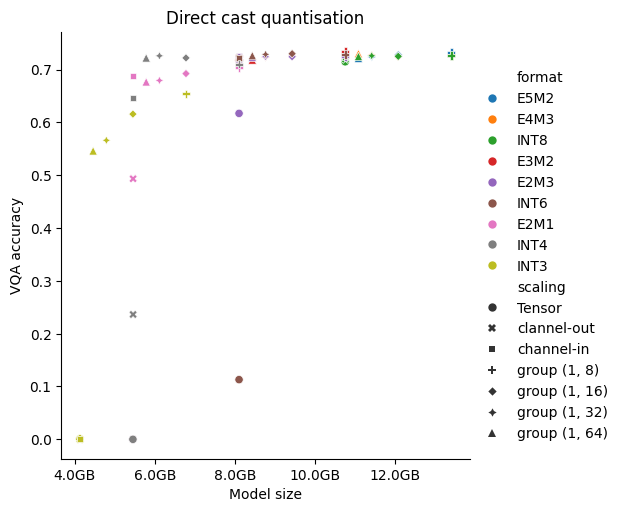

In [7]:
# Plot VQA results

p = sns.relplot(df_vqa, x="n_bytes", y="accuracy", hue="format", style="scaling")
ax = p.ax
ax.set_xlabel("Model size")
ax.set_ylabel("VQA accuracy")
ax.set_title("Direct cast quantisation")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 1e9}GB"))

In [8]:
merged_df = pd.merge(df_entropy, df_vqa, on=["format", "scaling"])

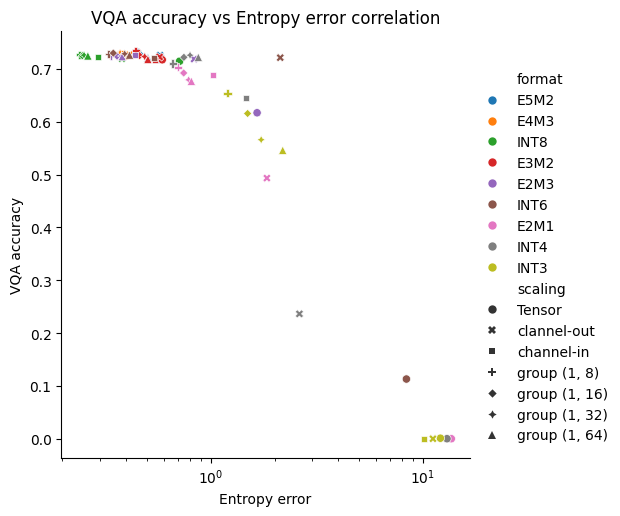

In [14]:
# NOTE: Should ignore channel-out scaling
p = sns.relplot(merged_df, x="entropy_rmse", y="accuracy", hue="format", style="scaling")
ax = p.ax
ax.set_ylabel("VQA accuracy")
ax.set_xlabel("Entropy error")
ax.set_xscale("log")
ax.set_title("VQA accuracy vs Entropy error correlation")
plt.show()